In [1]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from tabpfn import TabPFNClassifier, TabPFNRegressor
import pandas as pd
import numpy as np

# Load data
file_path = 'Manchester_data.csv'
data = pd.read_csv(file_path)

In [2]:
# Assuming 'grain_areas_pix' is a column in the dataframe 'data'
data['grain_areas_pix'] = data['grain_areas_pix'].apply(eval)
data['grain_areas_um2'] = data['grain_areas_um2'].apply(eval)
data['grain_strains'] = data['grain_strains'].apply(eval)
data['timepoints'] = data['timepoints'].apply(eval)
data['grain_ids'] = data['grain_ids'].apply(eval)
data['phase_ids'] = data['phase_ids'].apply(eval)

data['fraction'] = data['grain_areas_pix'].apply(lambda x: np.array(x) / x[0])

In [3]:
data_exploded = data.explode(['timepoints', 'grain_ids', 'phase_ids', 'grain_areas_pix', 'grain_areas_um2', 'grain_strains', 'fraction'])
data_exploded['timepoints'] = data_exploded['timepoints'].astype(float)
data_exploded['grain_ids'] = data_exploded['grain_ids'].astype(int)
data_exploded['phase_ids'] = data_exploded['phase_ids'].astype(int)
data_exploded['grain_areas_pix'] = data_exploded['grain_areas_pix'].astype(float)
data_exploded['grain_areas_um2'] = data_exploded['grain_areas_um2'].astype(float)
data_exploded['grain_strains'] = data_exploded['grain_strains'].astype(float)
data_exploded['fraction'] = data_exploded['fraction'].astype(float)
print(data_exploded)

     track_id  timepoints  grain_ids  phase_ids  grain_areas_pix  \
0         3.0         0.0         10          2             13.0   
0         3.0         1.0         32          1             25.0   
0         3.0         2.0         49          1             18.0   
0         3.0         3.0         89          1             27.0   
0         3.0         4.0         52          1             16.0   
..        ...         ...        ...        ...              ...   
472    5614.0         1.0       5047          2              9.0   
472    5614.0         2.0       4682          2              9.0   
472    5614.0         3.0       4623          2              8.0   
472    5614.0         4.0       4523          2              9.0   
472    5614.0         5.0       4138          2              5.0   

     grain_areas_um2  grain_strains  fraction  
0           0.714111       0.002160  1.000000  
0           1.373291       0.035532  1.923077  
0           0.988770       0.034001  1.

In [4]:
data_exploded.to_csv('data_exploded_output.csv', index=False)

In [5]:
fcc_data = data_exploded[data_exploded['phase_ids'] == 2]
print(fcc_data.shape)

(1409, 8)


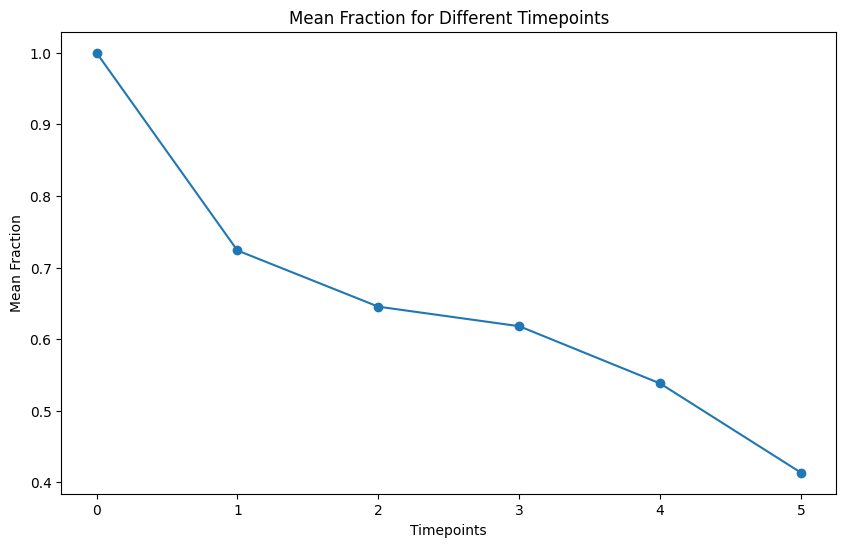

In [6]:
import matplotlib.pyplot as plt

# Group by 'timepoints' and calculate the mean of 'fraction'
mean_fraction = fcc_data.groupby('timepoints')['fraction'].mean()

# Plot the mean fraction for different timepoints
plt.figure(figsize=(10, 6))
mean_fraction.plot(kind='line', marker='o')
plt.xlabel('Timepoints')
plt.ylabel('Mean Fraction')
plt.title('Mean Fraction for Different Timepoints')
plt.show()

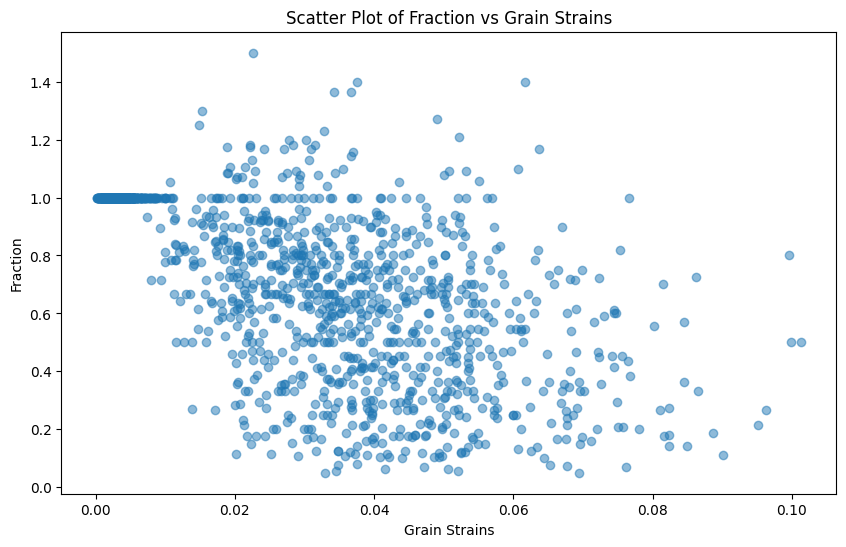

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(fcc_data['grain_strains'], fcc_data['fraction'], alpha=0.5)
plt.xlabel('Grain Strains')
plt.ylabel('Fraction')
plt.title('Scatter Plot of Fraction vs Grain Strains')
plt.show()

In [8]:
# Clip the values of 'fraction' to 1
fcc_data['fraction'] = fcc_data['fraction'].clip(upper=1)
fcc_data.to_csv('fcc_data.csv', index=False)

/var/folders/vw/j1nwntjj4x303ymlrbw7ypj40000gn/T/ipykernel_38457/3991001601.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fcc_data['fraction'] = fcc_data['fraction'].clip(upper=1)


Model Training

Correlation analysis

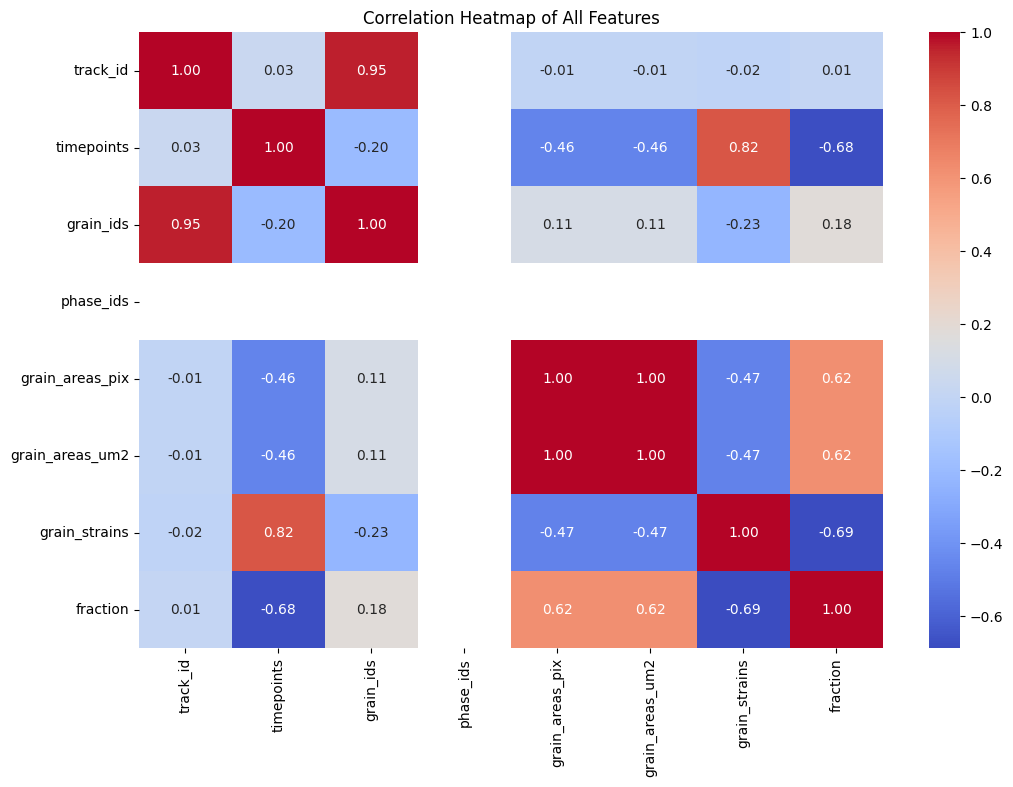

In [9]:
import seaborn as sns

import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = fcc_data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Features')
plt.show()

In [10]:
X = fcc_data[['timepoints', 'grain_ids', 'phase_ids', 'grain_areas_pix',
       'grain_areas_um2', 'grain_strains']]

y = fcc_data['fraction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

Model Summary

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from tabpfn import TabPFNRegressor
from autogluon.tabular import TabularPredictor
from sklearn.linear_model import LinearRegression

# Define a function to evaluate the model
def evaluate_model(model, X_train, y_train):
    r2_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    mse_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mae_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return np.mean(r2_scores), -np.mean(mse_scores), -np.mean(mae_scores)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(),
    'XGB Regressor': XGBRegressor(),
    'LGBM Regressor': LGBMRegressor(verbose=-1),
    'CatBoost Regressor': CatBoostRegressor(verbose=0),
    'TabPFN Regressor': TabPFNRegressor(),
    # 'AutoGluon Regressor': TabularPredictor(label='fraction', verbosity=0, eval_metric='r2')
}

# Evaluate models using cross-validation
results = []
for name, model in models.items():
    if name != 'AutoGluon Regressor':
        r2, mse, mae = evaluate_model(model, X, y)
    else:
        # Only apply to AutoGluon
        model.fit(train_data)
        preds = model.predict(test_data.drop(columns=['fraction']))
        r2 = r2_score(test_data['fraction'], preds)
        mse = mean_squared_error(test_data['fraction'], preds)
        mae = mean_absolute_error(test_data['fraction'], preds)
    results.append({'Model': name, 'R2 Score': r2, 'MSE': mse, 'MAE': mae})

# Create a DataFrame for the results
results_df = pd.DataFrame(results)

# Rank models by R2 Score
results_df = results_df.sort_values(by='R2 Score', ascending=False)

# Display the results
print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 604
[LightGBM] [Info] Number of data points in the train set: 1127, number of used features: 5
[LightGBM] [Info] Start training from score 0.727381
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 600
[LightGBM] [Info] Number of data points in the train set: 1127, number of used features: 5
[LightGBM] [Info] Start training from score 0.737887
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 602
[LightGBM] [Info] Number of data points in the train set: 1127, number of used features: 5
[LightGBM] [Info] Start training fro

Individual models for testing and details

In [12]:
# Initialize a regressor
reg = CatBoostRegressor(verbose=0)

# Perform cross-validation
cv_scores = cross_val_score(reg, X, y, cv=5, scoring='r2')
print("Cross-validated R-squared scores:", cv_scores)
print("Mean R-squared score:", np.mean(cv_scores))

Cross-validated R-squared scores: [0.6873225  0.76062152 0.7876747  0.82397909 0.74774535]
Mean R-squared score: 0.7614686308500793


In [13]:
reg = LGBMRegressor(verbose=-1)

# Perform cross-validation
cv_scores = cross_val_score(reg, X, y, cv=5, scoring='r2')
print("Cross-validated R-squared scores:", cv_scores)
print("Mean R-squared score:", np.mean(cv_scores))

Cross-validated R-squared scores: [0.74249042 0.7621473  0.77908925 0.81420843 0.74956435]
Mean R-squared score: 0.769499951109309


In [21]:
from sklearn.linear_model import LinearRegression

# Initialize the linear regression model
reg = LinearRegression()

cv_scores = cross_val_score(reg, X, y, cv=5, scoring='r2')
print("Cross-validated R-squared scores:", cv_scores)
print("Mean R-squared score:", np.mean(cv_scores))

Cross-validated R-squared scores: [0.55170421 0.65617306 0.5388709  0.56170303 0.6419476 ]
Mean R-squared score: 0.5900797608325131


In [15]:
reg = RandomForestRegressor()
# Perform cross-validation
cv_scores = cross_val_score(reg, X, y, cv=5, scoring='r2')
print("Cross-validated R-squared scores:", cv_scores)
print("Mean R-squared score:", np.mean(cv_scores))

Cross-validated R-squared scores: [0.72337773 0.77550134 0.75871945 0.82350295 0.77730648]
Mean R-squared score: 0.771681590078408


In [16]:
reg.fit(X_train, y_train)
# Get feature importances
feature_importances = reg.feature_importances_
# Create a DataFrame for feature importances
feature_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Display the DataFrame
feature_importances_df

,Feature,Importance
4,grain_areas_um2,0.394919
3,grain_areas_pix,0.349741
5,grain_strains,0.152917
1,grain_ids,0.062469
0,timepoints,0.039955
2,phase_ids,0.000000


In [17]:
reg = XGBRegressor()
cv_scores = cross_val_score(reg, X, y, cv=5, scoring='r2')
print("Cross-validated R-squared scores:", cv_scores)
print("Mean R-squared score:", np.mean(cv_scores))

Cross-validated R-squared scores: [0.67755543 0.70932332 0.7476561  0.80881289 0.71675727]
Mean R-squared score: 0.7320209998951541


In [18]:
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor

reg = TabPFNRegressor()
cv_scores = cross_val_score(reg, X, y, cv=5, scoring='r2')
print("Cross-validated R-squared scores:", cv_scores)
print("Mean R-squared score:", np.mean(cv_scores))

Cross-validated R-squared scores: [0.73952711 0.77031491 0.81072786 0.82775148 0.78585917]
Mean R-squared score: 0.7868361061287379


In [ ]:
from autogluon.tabular import TabularPredictor

reg = TabularPredictor(label='fraction', verbosity=0, eval_metric='r2').fit(train_data=train_data)
reg.evaluate(test_data)

{'r2': 0.8096952874983863,
 'root_mean_squared_error': -0.12700586197993036,
 'mean_squared_error': -0.01613048897726512,
 'mean_absolute_error': -0.0838944559973614,
 'pearsonr': 0.901541470626324,
 'median_absolute_error': -0.05463787555694577}

In [27]:
reg.leaderboard(fcc_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForestMSE,0.909481,0.817355,r2,0.049058,0.027594,0.240601,0.049058,0.027594,0.240601,1,True,5
1,LightGBMLarge,0.908677,0.787689,r2,0.018034,0.002215,3.178673,0.018034,0.002215,3.178673,1,True,11
2,XGBoost,0.906911,0.817868,r2,0.005437,0.001080,0.491700,0.005437,0.001080,0.491700,1,True,9
3,ExtraTreesMSE,0.900311,0.782181,r2,0.053572,0.026665,0.199859,0.053572,0.026665,0.199859,1,True,7
4,CatBoost,0.899625,0.819871,r2,0.005761,0.000540,0.907887,0.005761,0.000540,0.907887,1,True,6
5,WeightedEnsemble_L2,0.882772,0.831053,r2,0.015873,0.004770,3.018037,0.001401,0.000330,0.034280,2,True,12
6,LightGBM,0.880349,0.829673,r2,0.003109,0.000616,0.698348,0.003109,0.000616,0.698348,1,True,4
7,LightGBMXT,0.861233,0.813634,r2,0.008579,0.001606,0.820312,0.008579,0.001606,0.820312,1,True,3
8,NeuralNetTorch,0.844516,0.813834,r2,0.005926,0.002744,1.793709,0.005926,0.002744,1.793709,1,True,10
9,NeuralNetFastAI,0.843488,0.811938,r2,0.017646,0.003073,0.419617,0.017646,0.003073,0.419617,1,True,8
